dataset audit and error-driven analysis

For :
* dataset intigrity verfication --> Every image must have the correct annotation file.
✅ Every .jpg has a .txt label
✅ Every .txt belongs to an existing image
❌ No missing labels
❌ No orphan labels

* annotation quality validation --> Ensure that the dataset labels (bounding boxes) are accurate, complete, and reliable before training the YOLO model.


In [2]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import cv2 
import matplotlib.pyplot as plt
import collections as Counter  
import yaml


In [13]:
from pathlib import Path

DATASET = Path(
    r"D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV"
)


SPLITS = {

    "train": {
        "images": DATASET / "images" / "train",
        "labels": DATASET / "labels" / "train"
    },

    "val": {
        "images": DATASET / "images" / "val",
        "labels": DATASET / "labels" / "val"
    },

    "test": {
        "images": DATASET / "images" / "test",
        "labels": DATASET / "labels" / "test"
    }

}


print(SPLITS)

{'train': {'images': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/images/train'), 'labels': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/labels/train')}, 'val': {'images': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/images/val'), 'labels': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/labels/val')}, 'test': {'images': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/images/test'), 'labels': WindowsPath('D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/labels/test')}}


In [9]:
for folder in [
    DATASET / "images",
    DATASET / "labels"
]:
    
    print("\nFOLDER:", folder)

    for item in folder.iterdir():
        print(item)


FOLDER: D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\test
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\train
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val

FOLDER: D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\test
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\test.cache
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train.cache
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\val
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\val.cache


verify images and labels 

In [14]:
from pathlib import Path


def get_images(folder):

    extensions = [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp"
    ]

    files = []

    for ext in extensions:
        files.extend(folder.glob(ext))

    return files



def check_split(split):

    image_dir = split["images"]
    label_dir = split["labels"]

    images = get_images(image_dir)

    labels = list(label_dir.glob("*.txt"))


    image_names = set(
        img.stem for img in images
    )

    label_names = set(
        lbl.stem for lbl in labels
    )


    return {
        "images": len(images),
        "labels": len(labels),
        "missing_labels": len(image_names - label_names),
        "missing_images": len(label_names - image_names)
    }

In [15]:
summary = []

for split_name, paths in SPLITS.items():

    result = check_split(paths)

    result["split"] = split_name

    summary.append(result)


dataset_summary = pd.DataFrame(summary)

dataset_summary

,images,labels,missing_labels,missing_images,split
0,5200,5200,0,0,train
1,2600,2600,0,0,val
2,2200,2200,0,0,test


In [19]:
def validate_labels(label_dir):

    errors = []

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()


        # empty label file
        if len(lines) == 0:
            errors.append(
                [
                    label_file.name,
                    None,
                    "empty_file"
                ]
            )
            continue


        for line_number, line in enumerate(lines):

            values = line.strip().split()


            # wrong number of values
            if len(values) != 5:
                errors.append(
                    [
                        label_file.name,
                        line_number,
                        "wrong_number_of_values"
                    ]
                )
                continue


            cls, x, y, w, h = map(float, values)


            if cls != 0:
                errors.append(
                    [
                        label_file.name,
                        line_number,
                        "wrong_class"
                    ]
                )


            if not (0 <= x <= 1):
                errors.append(
                    [
                        label_file.name,
                        line_number,
                        "invalid_x"
                    ]
                )


            if not (0 <= y <= 1):
                errors.append(
                    [
                        label_file.name,
                        line_number,
                        "invalid_y"
                    ]
                )


            if w <= 0 or h <= 0:
                errors.append(
                    [
                        label_file.name,
                        line_number,
                        "invalid_size"
                    ]
                )


    return pd.DataFrame(
        errors,
        columns=[
            "file",
            "line",
            "error"
        ]
    )

In [20]:
train_errors = validate_labels(
    SPLITS["train"]["labels"]
)

val_errors = validate_labels(
    SPLITS["val"]["labels"]
)

test_errors = validate_labels(
    SPLITS["test"]["labels"]
)


print("Train errors:", len(train_errors))
print("Val errors:", len(val_errors))
print("Test errors:", len(test_errors))

Train errors: 3
Val errors: 1
Test errors: 0


In [21]:
bad_file = SPLITS["train"]["labels"] / "01234.txt"

print(bad_file.read_text())

0 0.644792 0.745833 0.028125 0.025000


In [23]:
train_errors

,file,line,error
0,00579.txt,None,empty_file
1,00639.txt,None,empty_file
2,00724.txt,None,empty_file


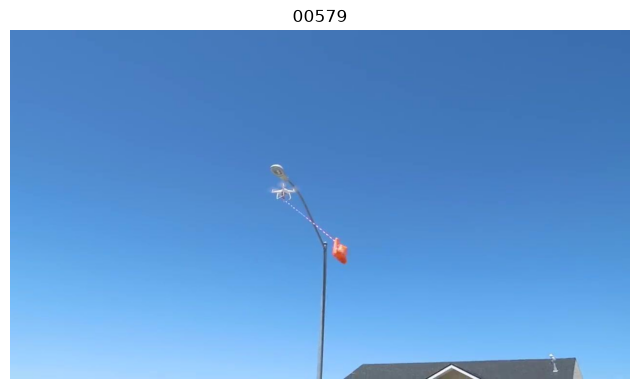

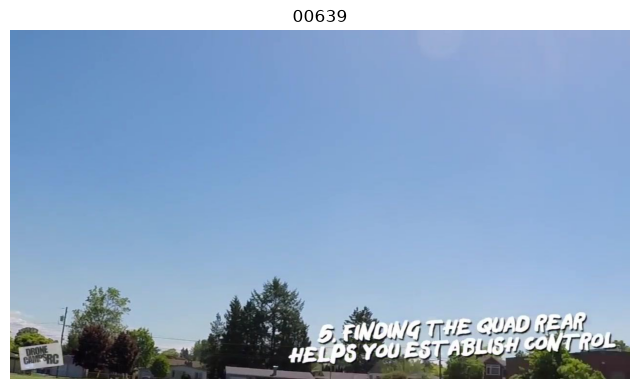

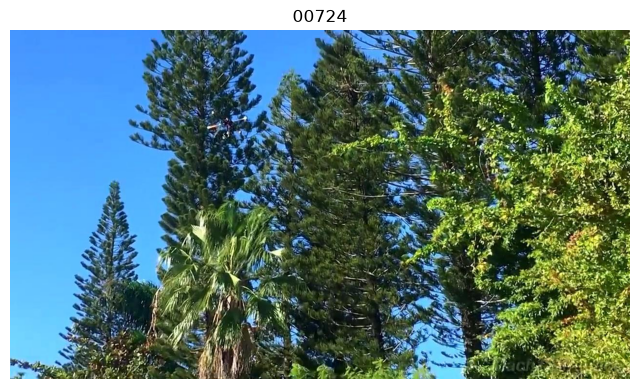

In [24]:
empty_files = [
    "00579",
    "00639",
    "00724"
]


for name in empty_files:

    img_path = SPLITS["train"]["images"] / f"{name}.jpg"

    img = cv2.imread(str(img_path))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")
    plt.show()

(1280, 720)


(1280, 720)


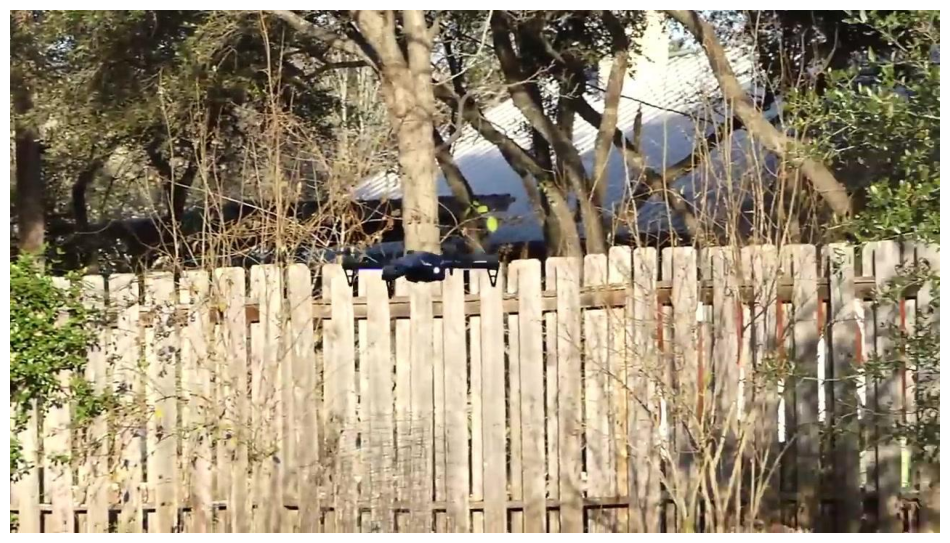

In [30]:
from PIL import Image
import matplotlib.pyplot as plt


img_path = SPLITS["train"]["images"] / "00524.jpg"

img = Image.open(img_path)

print(img.size)


plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO
from pathlib import Path

EXP2_BEST_MODEL = (
    Path(r"D:\master\Master_Drone_Detection\notebooks\runs")
    / "04_experiments"
    / "EXP002_YOLOv8s_high_resolution"
    / "YOLOv8s_960-3"
    / "weights"
    / "best.pt"
)

model_exp2 = YOLO(str(EXP2_BEST_MODEL))

img_path = SPLITS["train"]["images"] / "00724.jpg"

results = model_exp2.predict(
    source=str(img_path),
    imgsz=960,
    conf=0.1,
    device=0,
)

results[0].show()


image 1/1 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\train\00724.jpg: 544x960 (no detections), 36.5ms
Speed: 5.3ms preprocess, 36.5ms inference, 0.9ms postprocess per image at shape (1, 3, 544, 960)


In [7]:
from pathlib import Path
from ultralytics import YOLO


val_images = SPLITS["val"]["images"]

results = model_exp2.predict(
    source=str(val_images),
    imgsz=960,
    conf=0.25,
    device=0,
    save=False
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00001.jpg: 576x960 1 UAV, 48.2ms
image 2/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00002.jpg: 544x960 1 UAV, 24.2ms
image 3/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00003.jpg: 704x960 1 UAV, 42.3ms
image 4/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00004.jpg: 640x960 1 UAV, 39.5ms
i

after add annotation to  missing labels 

Re-run the annotation audit

In [11]:
model_exp2.val(
    data="D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/data.yaml",
    imgsz=960
)

Ultralytics 8.4.124  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 181.054.5 MB/s, size: 137.1 KB)
val: Scanning D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\val.cache... 2600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2600/2600  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 4.2it/s 38.9s0.3ss
                   all       2600       2621      0.973      0.913      0.946      0.656
Speed: 2.5ms preprocess, 8.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to D:\master\Master_Drone_Detection\notebooks\runs\detect\val-10


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026E69B5AFD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [39]:
train_errors = validate_labels(
    SPLITS["train"]["labels"]
)

print("Train errors:", len(train_errors))

Train errors: 1


In [40]:
train_errors

,file,line,error
0,00639.txt,None,empty_file


In [41]:
from pathlib import Path
import shutil

LABEL_DIR = Path(
    r"D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train"
)

IMAGE_DIR = Path(
    r"D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\train"
)

NO_DRONE_DIR = Path(
    r"D:\master\Master_Drone_Detection\06_results\no_drone_images"
)

NO_DRONE_DIR.mkdir(parents=True, exist_ok=True)


no_drone_images = []

for label_file in LABEL_DIR.glob("*.txt"):

    # check empty label
    if label_file.stat().st_size == 0:

        image_file = IMAGE_DIR / f"{label_file.stem}.jpg"

        if image_file.exists():
            no_drone_images.append(image_file)

            shutil.copy(
                image_file,
                NO_DRONE_DIR / image_file.name
            )


print("No drone images:", len(no_drone_images))
print("Saved to:", NO_DRONE_DIR)

No drone images: 1
Saved to: D:\master\Master_Drone_Detection\06_results\no_drone_images


In [69]:
def check_negative_samples(label_dir):
    print(label_dir)
    negative_samples = []        

    label_files  = list(label_dir.glob("*.txt"))
    for label_file in label_files:
        with open(label_file,"r" ,encoding="utf-8") as f:
            lines=f.readlines()

        if len(lines) == 0 :
            negative_samples.append(label_file.stem)
    return negative_samples



In [71]:
def find_negative_labels(label_dir):
    print(label_dir)
    negative_samples = []        

    label_files  = list(label_dir.glob("*.txt"))
    for label_file in label_files:
        label_file.stat().st_size == 0

        negative_samples.append(label_file)
    return negative_samples



In [72]:
for split_name, paths in SPLITS.items():
    negative_samples = find_negative_labels(
    SPLITS[split_name]["labels"]   
    )   
    print (result)

D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train
{'images': 2200, 'labels': 2200, 'missing_labels': 0, 'missing_images': 0}
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\val
{'images': 2200, 'labels': 2200, 'missing_labels': 0, 'missing_images': 0}
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\test
{'images': 2200, 'labels': 2200, 'missing_labels': 0, 'missing_images': 0}


In [80]:
metrics_exp2 = model_exp2.val(
    data="D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV/data.yaml",
    imgsz=960,
    device=0
)

Ultralytics 8.4.124  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
WARNING val: Slow image access detected (ping: 0.30.1 ms, read: 23.28.6 MB/s, size: 134.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\val.cache... 2600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2600/2600  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.5it/s 46.8s0.3ss
                   all       2600       2621      0.973      0.913      0.946      0.656
Speed: 3.5ms preprocess, 8.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to D:\master\Master_Drone_Detection\notebooks\runs\detect\val-7


In [ ]:
summary = metrics_exp2.results_dict

for k,v in summary.items():
    print(k, ":", v)

metrics/precision(B) : 0.9731454765538414
metrics/recall(B) : 0.9125091939490722
metrics/mAP50(B) : 0.9462581294312052
metrics/mAP50-95(B) : 0.6564084457227974
fitness : 0.6564084457227974


In [12]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO(str(EXP2_BEST_MODEL))

val_images = SPLITS["val"]["images"]

results = model.predict(
    source=str(val_images),
    imgsz=960,
    conf=0.25,
    device=0,
    stream=True
)

In [13]:
false_negative_images = []

for result in results:

    img_path = Path(result.path)

    # corresponding label
    label_path = SPLITS["val"]["labels"] / f"{img_path.stem}.txt"

    # check ground truth
    if label_path.exists():

        with open(label_path, "r") as f:
            gt_labels = f.readlines()

        gt_has_uav = len(gt_labels) > 0

        # predictions
        prediction_has_uav = len(result.boxes) > 0


        if gt_has_uav and not prediction_has_uav:
            false_negative_images.append(img_path)


print("False Negative images:", len(false_negative_images))


image 1/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00001.jpg: 576x960 1 UAV, 39.4ms
image 2/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00002.jpg: 544x960 1 UAV, 16.5ms
image 3/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00003.jpg: 704x960 1 UAV, 18.0ms
image 4/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00004.jpg: 640x960 1 UAV, 13.7ms
image 5/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00005.jpg: 576x960 6 UAVs, 10.3ms
image 6/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00006.jpg: 384x960 1 UAV, 16.2ms
image 7/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00007.jpg: 544x960 1 UAV, 12.2ms
image 8/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00008.jpg: 736x960 1 UAV, 19.3ms
image 9/2600 D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\

In [14]:
import shutil

FN_DIR = Path(
    "06_results/false_negative"
)

FN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


for img in false_negative_images:

    shutil.copy(
        img,
        FN_DIR / img.name
    )


print("Saved:", FN_DIR)

Saved: 06_results\false_negative


In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = false_negative_images[0]

image = Image.open(img)

print(img)
print(image.size)

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.show()

D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\val\00198.jpg
(1280, 720)


<Figure size 1200x800 with 1 Axes>

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches


img_path = false_negative_images[0]

image = Image.open(img_path)

label_path = SPLITS["val"]["labels"] / f"{img_path.stem}.txt"


fig, ax = plt.subplots(figsize=(12,8))

ax.imshow(image)


w, h = image.size


with open(label_path) as f:
    labels = f.readlines()


for label in labels:

    cls, xc, yc, bw, bh = map(float, label.split())

    # YOLO format -> pixel coordinates
    x = (xc - bw/2) * w
    y = (yc - bh/2) * h

    box_w = bw * w
    box_h = bh * h


    rect = patches.Rectangle(
        (x,y),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)


ax.set_title(img_path.name + " - Ground Truth UAV")
ax.axis("off")
plt.show()

<Figure size 1200x800 with 1 Axes>

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = false_negative_images[0]

img = Image.open(img_path)

print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

(1280, 720)


<Figure size 640x480 with 1 Axes>

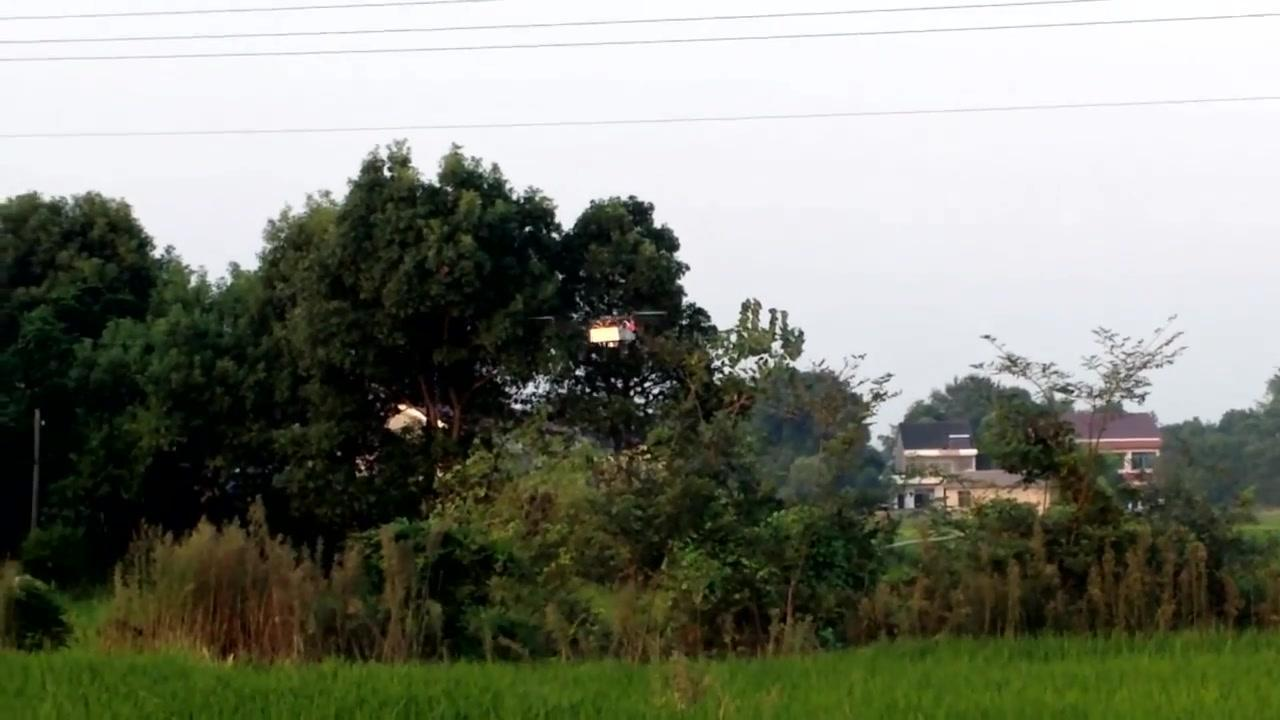

In [20]:
display(img)

In [6]:
img_path = false_negative_images[0]

label_path = SPLITS["val"]["labels"] / f"{img_path.stem}.txt"

print(img_path.name)
print(label_path)

print(open(label_path).read())

NameError: name 'false_negative_images' is not defined

In [23]:
def classify_size(row):

    if row["uav_width"] < 32 and row["uav_height"] < 32:
        return "Tiny"

    elif row["uav_width"] < 96 and row["uav_height"] < 96:
        return "Small"

    elif row["uav_width"] < 256 and row["uav_height"] < 256:
        return "Medium"

    else:
        return "Large"


fn_df["size_category"] = fn_df.apply(
    classify_size,
    axis=1
)


fn_df["size_category"].value_counts()

size_category
Tiny      66
Small     65
Medium     7
Large      3
Name: count, dtype: int64

In [24]:
fn_df["size_category"].value_counts()

size_category
Tiny      66
Small     65
Medium     7
Large      3
Name: count, dtype: int64

In [25]:
results = model_exp2.predict(
    source=false_negative_images,
    imgsz=960,
    conf=0.01,
    device=0
)


0: 960x960 2 UAVs, 519.5ms
1: 960x960 3 UAVs, 519.5ms
2: 960x960 2 UAVs, 519.5ms
3: 960x960 5 UAVs, 519.5ms
4: 960x960 7 UAVs, 519.5ms
5: 960x960 12 UAVs, 519.5ms
6: 960x960 (no detections), 519.5ms
7: 960x960 2 UAVs, 519.5ms
8: 960x960 1 UAV, 519.5ms
9: 960x960 4 UAVs, 519.5ms
10: 960x960 5 UAVs, 519.5ms
11: 960x960 1 UAV, 519.5ms
12: 960x960 6 UAVs, 519.5ms
13: 960x960 2 UAVs, 519.5ms
14: 960x960 9 UAVs, 519.5ms
15: 960x960 3 UAVs, 519.5ms
16: 960x960 2 UAVs, 519.5ms
17: 960x960 2 UAVs, 519.5ms
18: 960x960 3 UAVs, 519.5ms
19: 960x960 4 UAVs, 519.5ms
20: 960x960 3 UAVs, 519.5ms
21: 960x960 1 UAV, 519.5ms
22: 960x960 6 UAVs, 519.5ms
23: 960x960 4 UAVs, 519.5ms
24: 960x960 2 UAVs, 519.5ms
25: 960x960 2 UAVs, 519.5ms
26: 960x960 5 UAVs, 519.5ms
27: 960x960 8 UAVs, 519.5ms
28: 960x960 8 UAVs, 519.5ms
29: 960x960 13 UAVs, 519.5ms
30: 960x960 11 UAVs, 519.5ms
31: 960x960 3 UAVs, 519.5ms
32: 960x960 9 UAVs, 519.5ms
33: 960x960 6 UAVs, 519.5ms
34: 960x960 4 UAVs, 519.5ms
35: 960x960 4 UAVs, 